In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
from tqdm import tqdm
import gdsfactory as gf

from DirectionalCoupler_Pulley_GF import DirectionalCoupler_Pulley

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory
import addcopyfighandler

total_start = time.time()

# ----------------------------------------------------------------------------------
# Lumerical API path (uncomment for your machine) 
# ----------------------------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  # QP5
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP3
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP2

# ----------------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------------
WORKDIR   = Path().resolve()        # D:\...\scripts\directional_coupler
REPO_ROOT = WORKDIR.parents[1]     # D:\Ligentic_NU_1_TapeOut_April2026
os.chdir(WORKDIR)

data_save_dir = REPO_ROOT / "results_data" / "Data_directional_coupler_Pulley"
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORKDIR)
print("Data save   :", data_save_dir)

Working dir : D:\Ankit_data\Lumerical_scripts_Ligentec_NU_1\directional_coupler
Data save   : D:\Ankit_data\results_data\Data_directional_coupler_Pulley


In [2]:
#------------------------------------------------------------
# LUMERICAL SESSION
#------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  
import lumapi as lm

try:
    f.redraw()
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()

if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session.")

LumFileName = "DirCoup_MultiSweep_Pulley.lms"
LumFilePath = str(WORKDIR / LumFileName)
f.save(LumFilePath)

f.switchtolayout()
f.selectall()
f.delete()

Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [3]:
#------------------------------------------------------------
# PARAMETERS 
#------------------------------------------------------------
LambdaStart    = 1540E-9
LambdaStop     = 1560E-9

Height         = 800E-9
XLength        = 100E-6
YLength        = 20E-6

Material           = "Si3N4 (Silicon Nitride) - Luke"
use_index          = True
Index              = 1.97       # optional, used if material = '<Object defined dielectric>'
BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 500E-12
FrequencyPoints    = 200

print(f"Frequency Points: {FrequencyPoints}")

#------------------------------------------------------------
# SWEEP LISTS  (Width, ArcRadius, CouplingLength, Gap)
#------------------------------------------------------------

WgWidthIO         = 1.0E-6
Widths            = np.array([1600])* 1E-9
ArcRadii          = np.array([25])* 1E-6
# CouplingLengths   = np.array(np.arange(5,31,5))*1E-6
CouplingLengths   = np.array([10])*1E-6
# Gaps              = np.array(np.arange(300,1010,100))*1E-9
Gaps            = np.array([300])*1E-9
Eulers       = [1]



Frequency Points: 200


# Test Setup

  IN: center=(-88.84, 11.48) µm, orientation=180.0°
  TH: center=(77.92, 11.48) µm, orientation=0.0°
  CR: center=(20.00, -40.12) µm, orientation=270.0°
  BS: center=(-20.00, -40.12) µm, orientation=270.0°


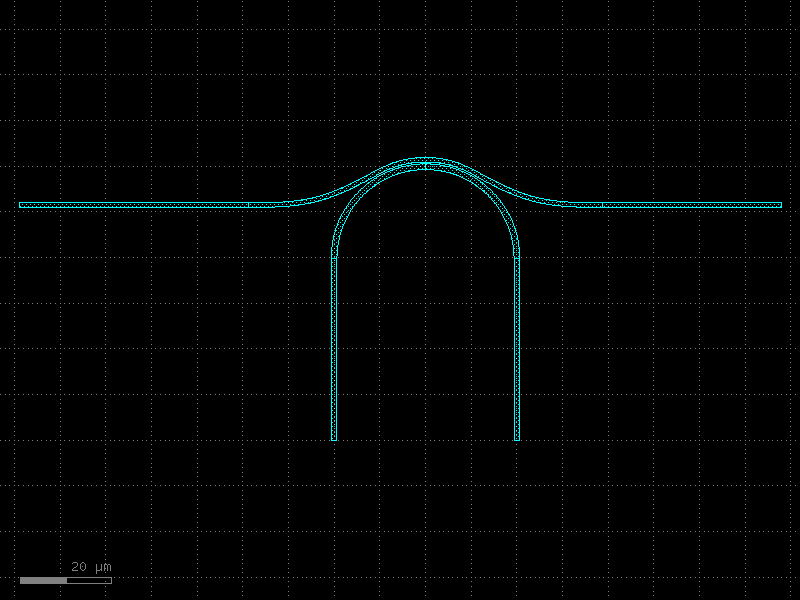

In [4]:
gf.clear_cache()

DC_Pulley = gf.Component("DC_Pulley")

DC_P = DC_Pulley << DirectionalCoupler_Pulley(
    TotLengthX = 100.0,
    InLengthX = 50.0,
    LengthY=2*YLength*1e6,
    Radius = 20.0,
    WgWidthIO = 1.0,
    WgWidth = 1.25,
    Gap = 0.4,
    CouplingLength = 20.0,
    BendRadiusIO = 30.0,
    Euler = 1,
    Layer = (2, 0))

# DC_Pulley.write_gds("DC_Pulley_test.gds")
# Verify ports
for p in DC_P.ports:
    print(f"  {p.name}: center=({p.dcenter[0]:.2f}, {p.dcenter[1]:.2f}) µm, orientation={p.orientation}°")
DC_Pulley.plot()

# Sweep

In [5]:
#------------------------------------------------------------
# HELPER FUNCTIONS
#------------------------------------------------------------
def start_section(name):
    print(f"🏃 {name}...")
    return time.time()

def end_section(start):
    print(f"✅ {time.time() - start:.1f}s")
    
#------------------------------------------------------------
# MULTI-DIMENSIONAL SWEEP
#------------------------------------------------------------

if use_index:
    csv_path = data_save_dir / f"DC_Pulley_Kappa2_vs_gap_n{Index:.2f}_R{ArcRadii[0]*1e6:.0f}_W{Widths[0]*1e9:.0f}nm.csv"
else:
    csv_path = data_save_dir / f"DC_Pulley_Kappa2_vs_gap_LumIndex_R{ArcRadii[0]*1e6:.0f}_W{Widths[0]*1e9:.0f}nm.csv"
all_results = []

if csv_path.exists():
    all_results = pd.read_csv(csv_path).to_dict('records')
    print(f"Loaded {len(all_results)} existing rows from {csv_path}")
else:
    all_results = []
    print("No existing CSV found — starting fresh.")


for WgWidth in tqdm(Widths, desc="WgWidth sweep", leave=True):
        for Euler in tqdm(Eulers, desc="      Euler sweep", leave=False):
            for Lc in tqdm(CouplingLengths, desc="        ThetaC sweep", leave=False):
                for Gap in tqdm(Gaps, desc="          Gap sweep", leave=False):

                    f.switchtolayout()
                    f.selectall()
                    f.delete()

                    tag = f"R{ArcRadii[0]*1e6:.0f}um_W{WgWidth*1e9:.0f}nm_WIO{WgWidthIO*1e9:.0f}nm_E{Euler}_Lc{Lc:.0f}_G{Gap*1e9:.0f}nm"
                    print(f"--- {tag} ---")
                    t = start_section("Geometry Setup")

                    #------------------------------------------------------------
                    # GDS GENERATION
                    #------------------------------------------------------------
                    gf.clear_cache()

                    dc = DirectionalCoupler_Pulley(
                            TotLengthX = 100.0,
                            InLengthX = 50.0,
                            LengthY=YLength*1e6,
                            Radius = ArcRadii[0] * 1e6,
                            WgWidthIO = WgWidthIO*1e6,
                            WgWidth = WgWidth * 1e6,
                            Gap = Gap * 1e6,
                            CouplingLength = Lc*1e6,
                            BendRadiusIO = ArcRadii[0] * 1e6,
                            Euler = Euler,
                            Layer = (2, 0))

                    gds_path = str(WORKDIR / "DC_Pulley_sweep.gds")
                    dc.write_gds(gds_path)
                    f.gdsimport(gds_path, dc.name, "2:0", Material, 0, Height)
                    
                    if use_index:
                        f.set("material", "<Object defined dielectric>")
                        f.set("index", Index)

                    #------------------------------------------------------------
                    # BOUNDING BOX & PORTS
                    #------------------------------------------------------------
                    bbox   = dc.bbox()
                    margin = (LambdaStop + LambdaStart) / 2
                    x_span = (bbox.right - bbox.left) * 1e-6 - 10*margin
                    y_span = (bbox.top - bbox.bottom) * 1e-6 - 2 * margin

                    y_min  = -y_span/4
                    y_max  = y_span/2

                    ports  = {p.name: (p.dcenter[0] * 1e-6, p.dcenter[1] * 1e-6) for p in dc.ports}
                    offsetX = 4e-6
                    offsetY = 2e-6

                    SourcePosX =  -(x_span/2) + offsetX
                    TH_PosX    =   (x_span/2) - offsetX
                    CR_PosX    = ArcRadii[0]

                    y0 = Gap+WgWidth/2 + ArcRadii[0]/2
                    Y0 = -Gap-WgWidth/2 + ArcRadii[0]/2

                    #------------------------------------------------------------
                    # varFDTD
                    #------------------------------------------------------------
                    f.addvarfdtd()
                    f.set("simulation time", SimulationTime)
                    f.set("x0", 0)
                    f.set("y0", Y0)
                    f.set("x", 0)
                    f.set("x span", x_span)
                    f.set("y", y0)
                    f.set("y span", y_span)
                    f.set("z", Height / 2)
                    f.set("z span", 8 * Height)
                    f.set("background material", BackgroundMaterial)
                    f.set("set simulation bandwidth", 1)
                    f.set("bandwidth", "broadband")
                    f.set("simulation wavelength min", LambdaStart)
                    f.set("simulation wavelength max", LambdaStop)
                    f.set("auto shutoff min", 1E-5)

                    f.set("x min bc", "PML")
                    f.set("x max bc", "PML")
                    f.set("y min bc", "PML")
                    f.set("y max bc", "PML")
                    f.set("z min bc", "PML")
                    f.set("z max bc", "PML")

                    #------------------------------------------------------------
                    # SOURCE 
                    #------------------------------------------------------------
                    f.addmodesource()
                    f.set("name", "ModeSource")
                    f.set("x", SourcePosX)
                    f.set("y", ports["IN"][1])
                    f.set("y span", 2 * WgWidth)
                    f.set("injection axis", "x-axis")
                    f.set("direction", "Forward")
                    f.set("amplitude", 1.0)
                    f.set("phase", 0)
                    f.set("mode selection", "fundamental mode")
                    f.set("set wavelength", 1)
                    f.set("wavelength start", LambdaStart)
                    f.set("wavelength stop", LambdaStop)

                    #------------------------------------------------------------
                    # MONITOR: Through 
                    #------------------------------------------------------------
                    f.adddftmonitor()
                    f.set("name", "TH")
                    f.set("monitor type", "Linear Y")
                    f.set("x", TH_PosX)
                    f.set("y", ports["TH"][1])
                    f.set("y span", 3 * WgWidth)
                    f.set("z", Height / 2)
                    f.set("override global monitor settings", 1)
                    f.set("use source limits", 1)
                    f.set("frequency points", FrequencyPoints)

                    #------------------------------------------------------------
                    # MONITOR: Cross (at o2)
                    #------------------------------------------------------------
                    f.adddftmonitor()
                    f.set("name", "CR")
                    f.set("monitor type", "Linear X")
                    f.set("x", CR_PosX)
                    f.set("y", ports["CR"][1]+YLength)
                    f.set("x span", 3 * WgWidth)
                    f.set("z", Height / 2)
                    f.set("override global monitor settings", 1)
                    f.set("use source limits", 1)
                    f.set("frequency points", FrequencyPoints)

                    #------------------------------------------------------------
                    # MONITOR: Field
                    #------------------------------------------------------------
                    f.adddftmonitor()
                    f.set("name", "Field Monitor")
                    f.set("monitor type", "2D Z-normal")
                    f.set("x", 0)
                    f.set("x span", 2 * (ArcRadii[0] + LambdaStop))
                    f.set("y", y0+5*WgWidth)
                    f.set("y span", ArcRadii[0])
                    f.set("z", Height / 2)
                    f.set("override global monitor settings", 1)
                    f.set("use wavelength spacing", 1)
                    f.set("wavelength center", 1550E-9)
                    f.set("wavelength span", 1E-9)
                    f.set("frequency points", 1)

                    end_section(t)
                    
#                     #------------------------------------------------------------
#                     # Run
#                     #------------------------------------------------------------
#                     t = start_section("Running solver")
#                     f.run()
#                     end_section(t)

#                     #------------------------------------------------------------
#                     # Extract Results
#                     #------------------------------------------------------------
#                     try:
#                         T_TH = f.getresult("TH", "T")
#                         T_CR = f.getresult("CR", "T")

#                         Tx_Through = np.abs(T_TH["T"].flatten())
#                         Tx_Cross   = np.abs(T_CR["T"].flatten())
#                         Wavelength = T_TH["lambda"].flatten()
#                     except Exception as e:
#                         print(f"  ⚠ SKIPPED | {e}")
#                         continue

#                     Tx_total_out = Tx_Through + Tx_Cross

#                     idx_1550        = np.argmin(np.abs(Wavelength - 1550e-9))
#                     kappa_sq_1550   = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
#                     loss_dB_1550    = -10 * np.log10(Tx_total_out[idx_1550])

#                     print(f"  κ²={kappa_sq_1550:.4f} | Loss={loss_dB_1550:.2f} dB")

#                     #------------------------------------------------------------
#                     # E-field plot (save only, no show)
#                     #------------------------------------------------------------
#                     E_field    = f.getresult("Field Monitor", "E")
#                     idx_1550_E = np.argmin(np.abs(E_field['lambda'].flatten() - 1550e-9))

#                     tag      = f"R{ArcRadii[0]*1e6:.0f}um_W{WgWidth*1e9:.0f}nm_gap{Gap*1e9:.0f}nm_E{Euler}_Lc{Lc*1e6:.0f}"
#                     fig_path = data_save_dir / f"Efield_DirCoup_{tag}.png"

#                     try:
#                         x = E_field['x'].flatten() * 1e6
#                         y = E_field['y'].flatten() * 1e6
#                         E_int = np.abs(E_field['E'][:, :, 0, idx_1550_E, 1]).T**2
#                         E_dB  = 10 * np.log10(E_int / E_int.max() + 1e-20)
#                         plt.figure(figsize=(6, 4))
#                         plt.imshow(E_dB,
#                                 aspect='auto', cmap='hot', origin='lower',
#                                 extent=[x.min(), x.max(), y.min(), y.max()],
#                                 vmin=-40, vmax=0)
#                         plt.xlabel('x (µm)')
#                         plt.ylabel('y (µm)')
#                         plt.colorbar(label='|Ey|² (dB)')
#                         plt.title(f'Field Profile at 1550nm | {tag}')
#                         plt.savefig(fig_path, dpi=150, bbox_inches='tight')
#                         plt.close('all')
#                     except Exception as e:
#                         print(f"  E-field save failed: {e}")
#                         plt.close('all')


#                     #------------------------------------------------------------
#                     # Append to results (replace if exists)
#                     #------------------------------------------------------------
#                     new_row = {
#                         "R"          : round(ArcRadii[0] * 1e6, 3),
#                         "W"          : round(WgWidth * 1e9, 3),
#                         "G"          : round(Gap * 1e9, 3),
#                         "E"          : Euler,
#                         "CL"         : round(Lc * 1e6, 3),
#                         "Kappa_sq"   : kappa_sq_1550,
#                         "Loss"       : loss_dB_1550,
#                         "Tx_Cross"   : Tx_Cross[idx_1550],
#                         "Tx_Through" : Tx_Through[idx_1550],
#                     }

#                     key = ("R", "W", "G", "E", "CL")
#                     match = next((i for i, r in enumerate(all_results)
#                                 if all(r[k] == new_row[k] for k in key)), None)
#                     if match is not None:
#                         all_results[match] = new_row
#                         tqdm.write(f"  Updated existing row | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")
#                     else:
#                         all_results.append(new_row)
#                         tqdm.write(f"  New row added | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")

#                     pd.DataFrame(all_results).to_csv(csv_path, index=False)

# #------------------------------------------------------------
# # MASTER CSV
# #------------------------------------------------------------
# df = pd.DataFrame(all_results)
# print(df)
# print(f"\nMaster CSV saved to {csv_path}")

No existing CSV found — starting fresh.


WgWidth sweep:   0%|          | 0/1 [00:00<?, ?it/s]




--- R25um_W1600nm_WIO1000nm_E1_Lc0_G300nm ---
🏃 Geometry Setup...








WgWidth sweep: 100%|██████████| 1/1 [00:01<00:00,  1.30s/it]

✅ 1.3s


In [6]:
#------------------------------------------------------------
# LOAD & PLOT RESULTS
#------------------------------------------------------------
# 1. Find and combine all relevant CSVs
csvs = sorted(data_save_dir.glob("DC_Pulley_Kappa2_vs_gap_*.csv"))

if not csvs:
    print("No CSVs found for plotting.")
else:
    df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)

    # 2. Group by Radius (R) and Euler (E) to create separate figure windows
    for (R, E), group_RE in df.groupby(["R", "E"]):
        euler_str = "Euler" if E == 1 else "Arc"
        
        # ==========================================
        # KAPPA² PLOT
        # ==========================================
        plt.figure(figsize=(8, 5))
        
        # Plot a line for each combination of Waveguide Width (W) and Coupling Length (CL)
        for (W, CL), Rows in group_RE.groupby(["W", "CL"]):
            Rows = Rows.sort_values("G") # Crucial: Sort by Gap for clean line plots
            plt.plot(Rows["G"], Rows["Kappa_sq"], '-o', linewidth=1.5, 
                    label=f'W={W:.0f}nm | Lc={CL:.0f}µm')
            
        plt.xlabel('Gap (nm)')
        plt.ylabel('κ²')
        plt.title(f'Coupling Efficiency | R={R:.0f}µm ({euler_str})')
        plt.legend(loc='best')
        plt.grid()
        plt.tight_layout()
        plt.savefig(data_save_dir / f"Kx_vs_gap_R{R:.0f}um_E{E}_all.png", dpi=150, bbox_inches='tight')
        
        mplcursors.cursor(hover=True)
        disconnect_zoom = zoom_factory(plt.gca())
        plt.show()

        # ==========================================
        # LOSS PLOT
        # ==========================================
        plt.figure(figsize=(8, 5))
        
        for (W, CL), Rows in group_RE.groupby(["W", "CL"]):
            Rows = Rows.sort_values("G")
            plt.plot(Rows["G"], Rows["Loss"], '-o', linewidth=1.5, 
                    label=f'W={W:.0f}nm | Lc={CL:.0f}µm')
            
        plt.xlabel('Gap (nm)')
        plt.ylabel('Loss (dB)')
        plt.title(f'Coupling Loss | R={R:.0f}µm ({euler_str})')
        plt.legend(loc='best')
        plt.grid()
        plt.tight_layout()
        plt.savefig(data_save_dir / f"Loss_vs_gap_R{R:.0f}um_E{E}_all.png", dpi=150, bbox_inches='tight')
        
        mplcursors.cursor(hover=True)
        disconnect_zoom = zoom_factory(plt.gca())
        plt.show()

No CSVs found for plotting.
